In [1]:
import pandas as pd
import time

In [2]:
from DatabaseCreator import DatabaseCreator
import CJDH_local_settings

#Run Database Creator
if __name__ == "__main__":
    db_creator = DatabaseCreator(db_settings=CJDH_local_settings.local_settings['FPL_Points_Predictor'])
    fpl_engine = db_creator.get_engine_for("fpl_data_analysis")

In [3]:
# Load df from sql
df = db_creator.run_sql("""SELECT *
                        FROM playergw_transformed
                          """)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148094 entries, 0 to 148093
Columns: 430 entries, player_name_id to saves_elo_p90sq_10
dtypes: float64(425), object(5)
memory usage: 485.8+ MB


Data overview:
Total rows: 148094
Columns: ['player_name_id', 'element', 'season', 'value', 'event', 'minutes', 'total_points', 'team_elo', 'opp_team_elo', 'position', 'goals_scored', 'bonus', 'bps', 'clean_sheets', 'goals_conceded', 'was_home', 'expected_goals', 'expected_assists', 'expected_goal_involvements', 'expected_goals_conceded', 'team_name', 'opp_team_name', 'cbi', 'defensive_contribution', 'recoveries', 'tackles', 'saves', 'player_season_minutes_total', 'player_season_points_per90', 'points_per90', 'expected_goals_per90', 'expected_assists_per90', 'expected_goals_conceded_per90', 'saves_per90', 'bps_per90', 'bonus_per90', 'cbi_per90', 'defensive_contribution_per90', 'recoveries_per90', 'tackles_per90', 'elo_diff', 'xgoal_involvements_x_defensive_cont_p90_at', 'xgoal_involvements_x_defensive_cont_at', 'xgoal_involvements_x_defensive_cont_p90_3', 'xgoal_involvements_x_defensive_cont_3', 'xgoal_involvements_x_defensive_cont_elo_p90_3', 'xgoal_involvements_x_defensive_cont_p90_5

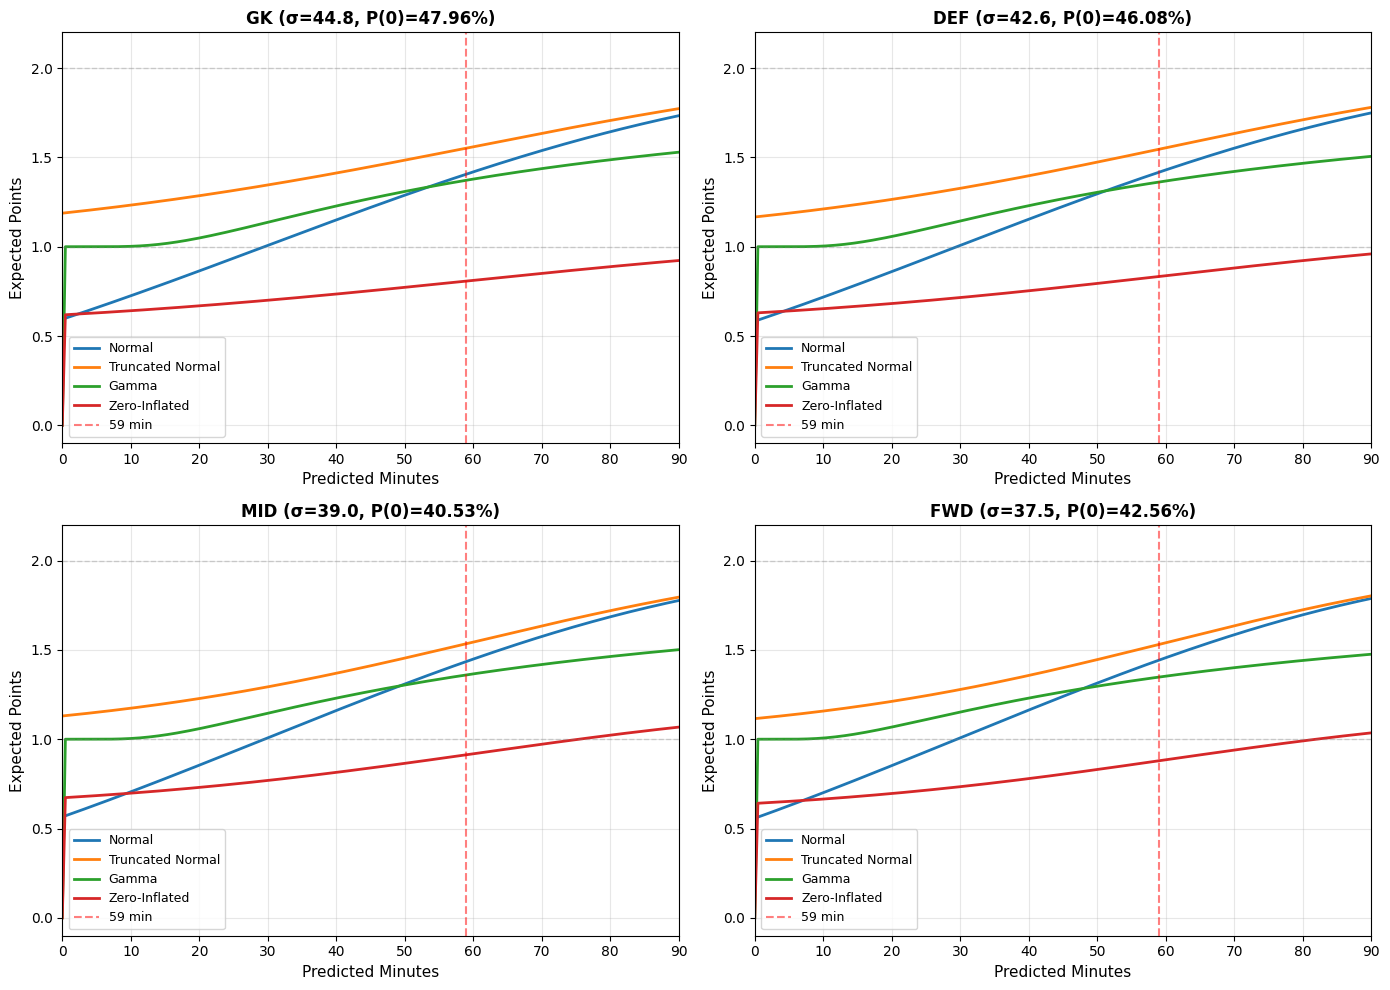

In [7]:
import pandas as pd
import numpy as np
from scipy import stats

class PositionSpecificPointsModel:
    """Model expected points with position-specific uncertainty parameters."""
    
    VALID_POSITIONS = ['GK', 'DEF', 'MID', 'FWD']
    
    def __init__(self, df, minutes_col='minutes', position_col='position'):
        """
        Initialize model by calculating position-specific parameters from data.
        
        Parameters:
        -----------
        df : DataFrame
            Historical data with minutes and positions
        minutes_col : str
            Column name for minutes played
        position_col : str
            Column name for position
        """
        self.minutes_col = minutes_col
        self.position_col = position_col
        
        # Filter for valid positions only
        df_filtered = df[df[position_col].isin(self.VALID_POSITIONS)].copy()
        
        if len(df_filtered) == 0:
            raise ValueError(f"No data found for valid positions: {self.VALID_POSITIONS}")
        
        print(f"Filtered to {len(df_filtered)} rows with valid positions: {self.VALID_POSITIONS}")
        
        # Calculate position-specific statistics
        self.position_stats = self._calculate_position_stats(df_filtered)
        
    def _calculate_position_stats(self, df):
        """Calculate mean, std, and zero-probability for each position."""
        stats_dict = {}
        
        for position in self.VALID_POSITIONS:
            pos_data = df[df[self.position_col] == position][self.minutes_col].dropna()
            
            if len(pos_data) == 0:
                print(f"Warning: No data found for position {position}")
                continue
            
            # Basic statistics
            mean_minutes = pos_data.mean()
            std_minutes = pos_data.std()
            
            # Handle case where std is 0 or very small
            if std_minutes < 0.1 or np.isnan(std_minutes):
                std_minutes = 1.0  # minimum std
            
            # Probability of playing 0 minutes
            p_zero = (pos_data == 0).mean()
            
            # For non-zero minutes, calculate conditional statistics
            non_zero = pos_data[pos_data > 0]
            if len(non_zero) > 0:
                mean_given_play = non_zero.mean()
                std_given_play = non_zero.std()
                if std_given_play < 0.1 or np.isnan(std_given_play):
                    std_given_play = 1.0
            else:
                mean_given_play = mean_minutes
                std_given_play = std_minutes
            
            # Coefficient of variation (for gamma distribution)
            cv = std_minutes / mean_minutes if mean_minutes > 0 else 0.5
            cv_given_play = std_given_play / mean_given_play if mean_given_play > 0 else 0.5
            
            stats_dict[position] = {
                'mean': mean_minutes,
                'std': std_minutes,
                'p_zero': p_zero,
                'mean_given_play': mean_given_play,
                'std_given_play': std_given_play,
                'cv': cv,
                'cv_given_play': cv_given_play,
                'n_samples': len(pos_data)
            }
        
        return pd.DataFrame(stats_dict).T
    
    def get_sigma(self, position):
        """Get standard deviation for a specific position."""
        if position not in self.position_stats.index:
            # Return overall average if position not found
            avg_std = self.position_stats['std'].mean()
            return avg_std if not np.isnan(avg_std) else 15.0
        return self.position_stats.loc[position, 'std']
    
    def get_p_zero(self, position):
        """Get probability of 0 minutes for a specific position."""
        if position not in self.position_stats.index:
            avg_p = self.position_stats['p_zero'].mean()
            return avg_p if not np.isnan(avg_p) else 0.1
        return self.position_stats.loc[position, 'p_zero']
    
    def predict_points(self, predicted_minutes, position, method='zero_inflated'):
        """
        Predict expected points given predicted minutes and position.
        
        Parameters:
        -----------
        predicted_minutes : float or array
            Predicted minutes for the player
        position : str or array
            Position(s) of the player(s) - must be one of GK, DEF, MID, FWD
        method : str
            'normal', 'truncated_normal', 'gamma', or 'zero_inflated'
        """
        # Handle single values
        if np.isscalar(predicted_minutes):
            predicted_minutes = np.array([predicted_minutes])
            position = np.array([position])
            single_value = True
        else:
            predicted_minutes = np.array(predicted_minutes)
            if np.isscalar(position):
                position = np.array([position] * len(predicted_minutes))
            else:
                position = np.array(position)
            single_value = False
        
        results = []
        
        for minutes, pos in zip(predicted_minutes, position):
            # Skip None or NaN positions
            if pos is None or (isinstance(pos, float) and np.isnan(pos)):
                results.append(np.nan)
                continue
            
            # Check if position is valid
            if pos not in self.VALID_POSITIONS:
                print(f"Warning: Invalid position '{pos}'. Must be one of {self.VALID_POSITIONS}")
                results.append(np.nan)
                continue
                
            sigma = self.get_sigma(pos)
            p_zero = self.get_p_zero(pos)
            
            try:
                if method == 'normal':
                    result = self._expected_points_normal(minutes, sigma)
                elif method == 'truncated_normal':
                    result = self._expected_points_truncated_normal(minutes, sigma)
                elif method == 'gamma':
                    cv = self.position_stats.loc[pos, 'cv'] if pos in self.position_stats.index else 0.5
                    result = self._expected_points_gamma(minutes, cv)
                elif method == 'zero_inflated':
                    result = self._expected_points_zero_inflated(minutes, sigma, p_zero)
                else:
                    raise ValueError(f"Unknown method: {method}")
                
                results.append(result)
            except Exception as e:
                print(f"Warning: Error calculating for position {pos}, minutes {minutes}: {e}")
                results.append(np.nan)
        
        results = np.array(results)
        return results[0] if single_value else results
    
    def _expected_points_normal(self, mu, sigma):
        """Expected points using normal distribution."""
        if np.isnan(mu) or np.isnan(sigma):
            return np.nan
        p_zero = stats.norm.cdf(0, loc=mu, scale=sigma)
        p_one_point = stats.norm.cdf(59, loc=mu, scale=sigma) - p_zero
        p_two_points = 1 - stats.norm.cdf(59, loc=mu, scale=sigma)
        return 0 * p_zero + 1 * p_one_point + 2 * p_two_points
    
    def _expected_points_truncated_normal(self, mu, sigma):
        """Expected points using truncated normal."""
        if np.isnan(mu) or np.isnan(sigma):
            return np.nan
        a = -mu / sigma
        p_one = stats.truncnorm.cdf(59, a, np.inf, loc=mu, scale=sigma)
        p_two = 1 - stats.truncnorm.cdf(59, a, np.inf, loc=mu, scale=sigma)
        return 1 * p_one + 2 * p_two
    
    def _expected_points_gamma(self, mu, cv):
        """Expected points using gamma distribution."""
        if mu <= 0 or np.isnan(mu) or np.isnan(cv):
            return 0.0
        shape = 1 / (cv ** 2)
        scale = mu / shape
        p_one = stats.gamma.cdf(59, shape, scale=scale)
        p_two = 1 - stats.gamma.cdf(59, shape, scale=scale)
        return 1 * p_one + 2 * p_two
    
    def _expected_points_zero_inflated(self, mu, sigma, p_zero):
        """Expected points using zero-inflated normal."""
        if mu <= 0 or np.isnan(mu) or np.isnan(sigma):
            return 0.0
        
        # Conditional probabilities given m > 0
        a = -mu / sigma
        p_one_given_play = stats.truncnorm.cdf(59, a, np.inf, loc=mu, scale=sigma)
        p_two_given_play = 1 - p_one_given_play
        
        return (p_zero * 0 + 
                (1 - p_zero) * (1 * p_one_given_play + 2 * p_two_given_play))
    
    def summary(self):
        """Print summary statistics by position."""
        print("\nPosition-Specific Statistics (GK, DEF, MID, FWD)")
        print("=" * 100)
        print(self.position_stats.to_string())
        print("=" * 100)
        return self.position_stats


# Usage with your existing dataframe
if __name__ == "__main__":
    print("Data overview:")
    print(f"Total rows: {len(df)}")
    print(f"Columns: {df.columns.tolist()}")
    print(f"\nPosition distribution:")
    print(df['position'].value_counts())
    
    # Initialize model with your data
    model = PositionSpecificPointsModel(df, minutes_col='minutes', position_col='position')
    
    # Display position statistics
    position_stats = model.summary()
    
    # Example: Add expected points to your dataframe
    # If you have predicted minutes in a column called 'predicted_minutes'
    if 'predicted_minutes' in df.columns:
        # Filter to valid positions only
        df_valid = df[df['position'].isin(model.VALID_POSITIONS)].copy()
        
        df_valid['expected_points'] = model.predict_points(
            df_valid['predicted_minutes'].values,
            df_valid['position'].values,
            method='zero_inflated'
        )
        
        print("\n\nDataFrame with expected points (sample):")
        print(df_valid[['position', 'predicted_minutes', 'expected_points']].head(10))
    
    # Make individual predictions for each position
    print("\n\nExample Individual Predictions:")
    print("=" * 70)
    print(f"{'Minutes':<10} {'Position':<15} {'Expected Points':<15}")
    print("-" * 70)
    
    for position in model.VALID_POSITIONS:
        for minutes in [20, 40, 60]:
            exp_points = model.predict_points(minutes, position, method='zero_inflated')
            if exp_points is not None and not np.isnan(exp_points):
                print(f"{minutes:<10} {position:<15} {exp_points:<15.3f}")
            else:
                print(f"{minutes:<10} {position:<15} {'N/A':<15}")
    
    # Visualize by position
    import matplotlib.pyplot as plt
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()
    
    minutes_range = np.linspace(0, 90, 200)
    
    for idx, pos in enumerate(model.VALID_POSITIONS):
        ax = axes[idx]
        
        # Get position-specific parameters
        sigma = model.get_sigma(pos)
        p_zero = model.get_p_zero(pos)
        
        # Calculate expected points for each method
        methods = {
            'Normal': 'normal',
            'Truncated Normal': 'truncated_normal',
            'Gamma': 'gamma',
            'Zero-Inflated': 'zero_inflated'
        }
        
        for label, method in methods.items():
            predictions = model.predict_points(
                minutes_range,
                np.full(len(minutes_range), pos),
                method=method
            )
            ax.plot(minutes_range, predictions, linewidth=2, label=label)
        
        # Add reference lines
        ax.axhline(y=1, color='gray', linestyle='--', alpha=0.3, linewidth=1)
        ax.axhline(y=2, color='gray', linestyle='--', alpha=0.3, linewidth=1)
        ax.axvline(x=59, color='red', linestyle='--', alpha=0.5, linewidth=1.5, label='59 min')
        
        ax.set_xlabel('Predicted Minutes', fontsize=11)
        ax.set_ylabel('Expected Points', fontsize=11)
        ax.set_title(f'{pos} (σ={sigma:.1f}, P(0)={p_zero:.2%})', 
                    fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=9, loc='best')
        ax.set_ylim(-0.1, 2.2)
        ax.set_xlim(0, 90)
    
    plt.tight_layout()
    plt.savefig('position_specific_expected_points.png', dpi=150, bbox_inches='tight')
    print("\n\nPlot saved as 'position_specific_expected_points.png'")
    plt.show()